<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


Estimated time needed: **30** minutes


In this lab, you will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality. You will:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.

This lab equips you with the skills to effectively preprocess and clean real-world datasets, a crucial step in any data analysis project.


## Objectives


In this lab, you will perform the following:


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

### Step 1: Import Required Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [3]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [4]:
## Write your code here

dup_df=df[df.duplicated()]
dup_df.head(10)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


In [5]:
df.shape

(65437, 114)

##### Task 2: Remove the duplicate rows from the dataframe.



In [6]:
## Write your code here

df.drop_duplicates(inplace=True)

df.shape

(65437, 114)

### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [7]:
## Write your code here

null_values=df.isnull().sum()

print('Number of NaN values in each column that contains at least one NaN \n\n',null_values[null_values>0])

Number of NaN values in each column that contains at least one NaN 

 RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64


##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [8]:
## Write your code here

print('number of NaN in RemotWork:', null_values['RemoteWork'])

number of NaN in RemotWork: 10631


### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [9]:
## Write your code here

df['RemoteWork'].value_counts()

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [10]:
## Write your code here

most_frequent_RemoteWork=df['RemoteWork'].mode()[0]

most_frequent_RemoteWork

'Hybrid (some remote, some in-person)'

##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [11]:
## Write your code here

df['RemoteWork']=df['RemoteWork'].fillna(most_frequent_RemoteWork)
print('null values in RemoteWork after imputation:',df['RemoteWork'].isnull().sum())

null values in RemoteWork after imputation: 0


##### Task 8: Check for any compensation-related columns and describe their distribution.



       ConvertedCompYearly      CompTotal
count         2.343500e+04   3.374000e+04
mean          8.615529e+04  2.963841e+145
std           1.867570e+05  5.444117e+147
min           1.000000e+00   0.000000e+00
25%           3.271200e+04   6.000000e+04
50%           6.500000e+04   1.100000e+05
75%           1.079715e+05   2.500000e+05
max           1.625660e+07  1.000000e+150


 NaN values in compensation: 

 ConvertedCompYearly    42002
CompTotal              31697
dtype: int64


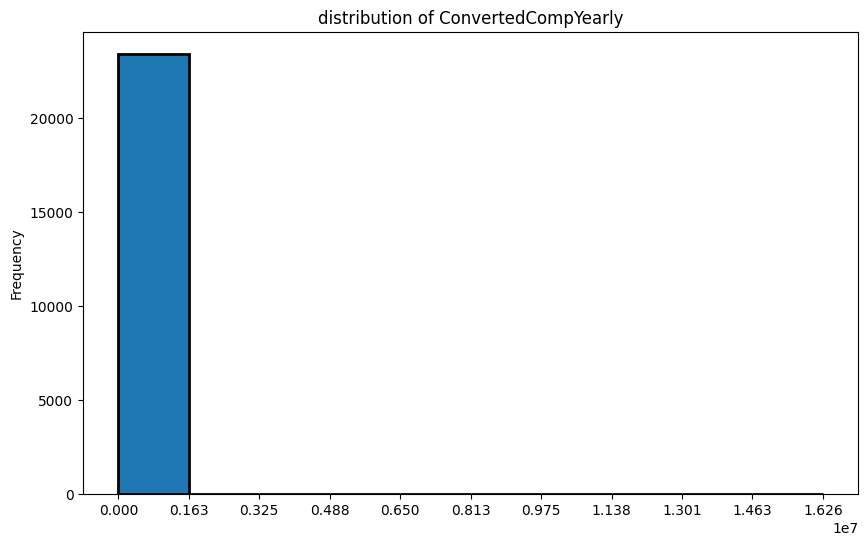

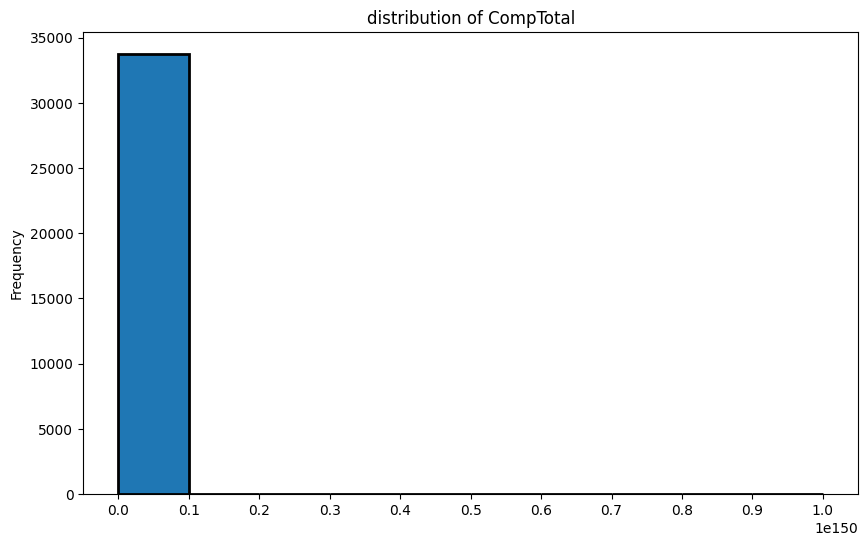

In [12]:
## Write your code here
print(df[['ConvertedCompYearly', 'CompTotal']].describe())

print('\n\n NaN values in compensation: \n\n',df[['ConvertedCompYearly', 'CompTotal']].isnull().sum())



entries_in_bin_Converted, bin_range_Converted=np.histogram(df['ConvertedCompYearly'].dropna(axis=0))
entries_in_bin_total, bin_range_total=np.histogram(df['CompTotal'].dropna(axis=0))

df['ConvertedCompYearly'].dropna(axis=0).plot(kind='hist', figsize=(10,6), xticks=bin_range_Converted, linewidth=2, edgecolor='black')
plt.title('distribution of ConvertedCompYearly')
plt.show()

df['CompTotal'].dropna(axis=0).plot(kind='hist', figsize=(10,6), xticks=bin_range_total, linewidth=2, edgecolor='black', bins=10)
plt.title('distribution of CompTotal')
plt.show()

These histograms look a bit off. Let's review them

In [13]:
print(entries_in_bin_Converted, entries_in_bin_total, bin_range_Converted, bin_range_total)

[23418    11     1     2     0     1     0     0     1     1] [33739     0     0     0     0     0     0     0     0     1] [1.00000000e+00 1.62566120e+06 3.25132140e+06 4.87698160e+06
 6.50264180e+06 8.12830200e+06 9.75396220e+06 1.13796224e+07
 1.30052826e+07 1.46309428e+07 1.62566030e+07] [0.e+000 1.e+149 2.e+149 3.e+149 4.e+149 5.e+149 6.e+149 7.e+149 8.e+149
 9.e+149 1.e+150]


There are some outliers; let's remove them with IQR method to get a clearer view of the compensation

In [14]:
converted_NaN_free=df['ConvertedCompYearly'].dropna(axis=0)
total_NaN_free=df['CompTotal'].dropna(axis=0)

Q1total=np.quantile(total_NaN_free, 0.25)
Q3total=np.quantile(total_NaN_free, 0.75)
total_IQR=Q3total-Q1total

total_max_value=Q3total+4*total_IQR #Using the standard 1.5 IQR removed nearly 1,000 responses, so to avoid losing a significant number of valid observations, the threshold was increased to 4 IQR to remove only extreme values(cleaned_converted size (22457,) with 1.5 IQR)
total_min_value=Q1total-1.5*total_IQR

#######################################################################################

Q1converted=np.quantile(converted_NaN_free, 0.25)
Q3converted=np.quantile(converted_NaN_free, 0.75)
converted_IQR=Q3converted-Q1converted

converted_max_value=Q3converted+4*converted_IQR
converted_min_value=Q1converted-1.5*converted_IQR



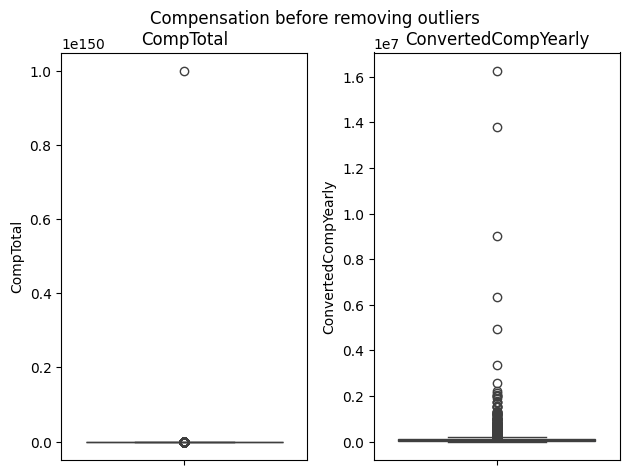

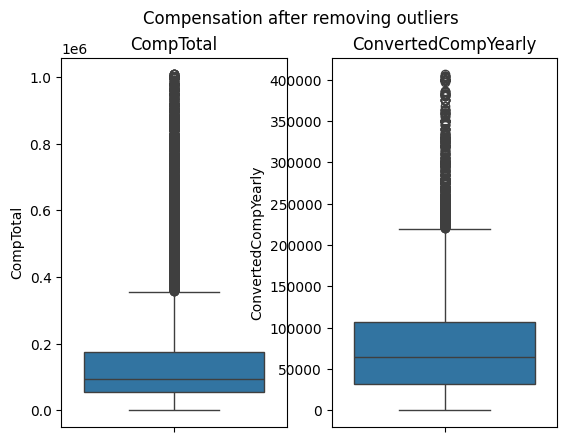

total size before cleaning (33740,) 
 cleaned_total size (29973,)
converted size before cleaning (23435,) 
 cleaned_converted size (23241,)


In [15]:
cleaned_total=total_NaN_free[(total_NaN_free<total_max_value) & (total_NaN_free>total_min_value)] 
cleaned_converted=converted_NaN_free[(converted_NaN_free<converted_max_value) & (converted_NaN_free>converted_min_value)] 

fig=plt.figure()
ax0=fig.add_subplot(1,2,1)
ax1=fig.add_subplot(1,2,2)
sns.boxplot(total_NaN_free, ax=ax0)
ax0.set_title('CompTotal')
sns.boxplot(converted_NaN_free, ax=ax1)
ax1.set_title('ConvertedCompYearly')
fig.tight_layout()
plt.suptitle('Compensation before removing outliers')
plt.show()

fig1=plt.figure()
ax2=fig1.add_subplot(1,2,1)
ax3=fig1.add_subplot(1,2,2)
sns.boxplot(cleaned_total, ax=ax2)
ax2.set_title('CompTotal')
sns.boxplot(cleaned_converted, ax=ax3)
ax3.set_title('ConvertedCompYearly')
fig.tight_layout()
plt.suptitle('Compensation after removing outliers')
plt.show()

print('total size before cleaning',total_NaN_free.shape,'\n cleaned_total size', cleaned_total.shape)
print('converted size before cleaning',converted_NaN_free.shape,'\n cleaned_converted size', cleaned_converted.shape)

       ConvertedCompYearly      CompTotal
count         2.343500e+04   3.374000e+04
mean          8.615529e+04  2.963841e+145
std           1.867570e+05  5.444117e+147
min           1.000000e+00   0.000000e+00
25%           3.271200e+04   6.000000e+04
50%           6.500000e+04   1.100000e+05
75%           1.079715e+05   2.500000e+05
max           1.625660e+07  1.000000e+150


 NaN values in compensation: 

 ConvertedCompYearly    42002
CompTotal              31697
dtype: int64


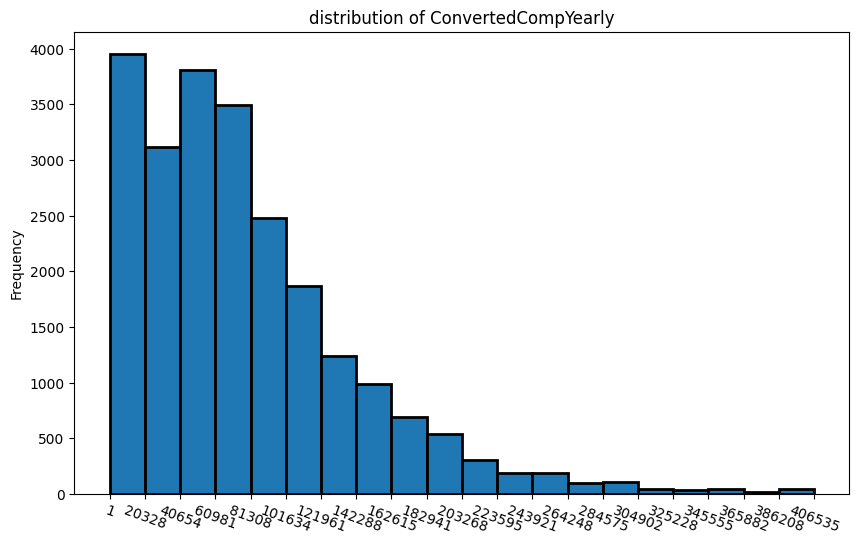

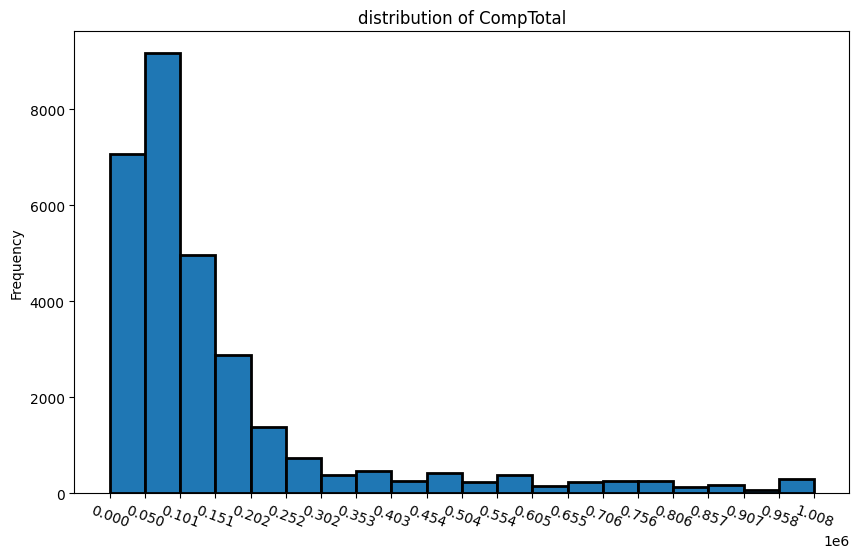

In [16]:
print(df[['ConvertedCompYearly', 'CompTotal']].describe())

print('\n\n NaN values in compensation: \n\n',df[['ConvertedCompYearly', 'CompTotal']].isnull().sum())



entries_in_bin_Converted, bin_range_Converted=np.histogram(cleaned_converted,20)
entries_in_bin_total, bin_range_total=np.histogram(cleaned_total,20)

cleaned_converted.plot(kind='hist', figsize=(10,6), xticks=bin_range_Converted, linewidth=2, edgecolor='black', bins=20)
plt.xticks(rotation=-20)
plt.title('distribution of ConvertedCompYearly')
plt.show()

cleaned_total.plot(kind='hist', figsize=(10,6), xticks=bin_range_total, linewidth=2, edgecolor='black', bins=20)
plt.xticks(rotation=-20)
plt.title('distribution of CompTotal')
plt.show()

The CompTotal column exhibits extreme skewness with most values concentrated below 250,000, but also contains extreme outliers reaching values as high as 1.0+150. Additionally, a large number of records exceed the 75th percentile + 4 IQR threshold, which suggests the presence of potentially incorrect or inconsistent entries in this column.

The ConvertedCompYearly column contains fewer records due to a higher proportion of missing values, but still includes over 23,000 observations. Its distribution is also right-skewed, with most values ranging between 1 and 200,000. Compared to CompTotal, this column appears more reliable, with fewer extreme values. Although the maximum value exceeds 16 million, given the sample size, such a value cannot be automatically classified as an outlier.

### Summary 


**In this lab, you focused on imputing missing values in the dataset.**

- Use the <code>pandas.read_csv()</code> function to load a dataset from a CSV file into a DataFrame.

- Download the dataset if it's not available online and specify the correct file path.



<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
